In [6]:
import transformers
import torch

print(transformers.__version__)
print(torch.__version__)
print(torch.cuda.is_available())



5.0.0
2.10.0+cu128
True


In [7]:
!pip install -q transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [8]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from datasets import Dataset

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [9]:
import gdown

url = "https://drive.google.com/file/d/1gND_ylSniEH7F7BTqEpS6QEqdg78Clkh/view?usp=sharing"

gdown.download(url,"df.pkl",fuzzy=True)

df = pd.read_pickle("df.pkl")

Downloading...
From (original): https://drive.google.com/uc?id=1gND_ylSniEH7F7BTqEpS6QEqdg78Clkh
From (redirected): https://drive.google.com/uc?id=1gND_ylSniEH7F7BTqEpS6QEqdg78Clkh&confirm=t&uuid=d3b45e20-f752-4a77-9506-7fc48b016679
To: /kaggle/working/df.pkl
100%|██████████| 1.22G/1.22G [00:07<00:00, 160MB/s]


In [134]:
df.head()

,id,target,comment_text,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,...,article_id,rating,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
0,59848,0,this is so cool it is like would you want your...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
1,59849,0,thank you this would make my life a lot less a...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
2,59852,0,this is such an urgent design problem kudos to...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
3,59855,0,is this something i will be able to install on...,0.000000,0.0,0.000000,0.00000,0.0,NaN,NaN,...,2006,rejected,0,0,0,0,0,0.0,0,4
4,59856,1,haha you guys are a bunch of losers,0.021277,0.0,0.021277,0.87234,0.0,0.0,0.0,...,2006,rejected,0,0,0,1,0,0.0,4,47


In [8]:
# The raw URL
url = "https://drive.google.com/file/d/1YatDph1Ndo-ETR2o_yOnYLlgtdxqrI01/view?usp=sharing"
output_filename = 'test_df.pkl'

# Use fuzzy=True so gdown strips away the Google HTML warning pages
file_path = gdown.download(url, output_filename, quiet=False, fuzzy=True)

# Read the file now that it is properly saved on disk
test_df = pd.read_pickle(file_path)
test_df.head()

Downloading...
From: https://drive.google.com/uc?id=1YatDph1Ndo-ETR2o_yOnYLlgtdxqrI01
To: /kaggle/working/test_df.pkl
100%|██████████| 29.1M/29.1M [00:00<00:00, 143MB/s] 


,id,comment_text
0,7097320,integrity means that you pay your debts does t...
1,7097321,this is malfeasance by the administrator and t...
2,7097322,rmiller101 spoken like a true elitist but look...
3,7097323,paul thank you for your kind words i do indeed...
4,7097324,sorry you missed high school eisenhower sent t...


In [5]:
df = df[["comment_text","target"]]

In [6]:
df.head()

,comment_text,target
0,this is so cool it is like would you want your...,0.000000
1,thank you this would make my life a lot less a...,0.000000
2,this is such an urgent design problem kudos to...,0.000000
3,is this something i will be able to install on...,0.000000
4,haha you guys are a bunch of losers,0.893617


In [135]:
df.size

81219195

In [11]:
df["target"] = (
    df["target"] >= 0.5
).astype(int)

In [12]:
df["target"].value_counts()

target
0    1660537
1     144334
Name: count, dtype: int64

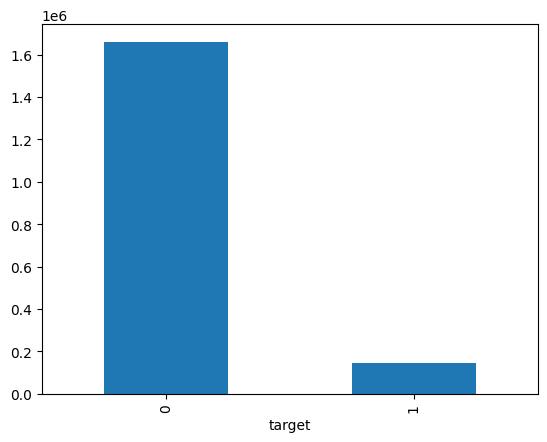

In [13]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(
    kind="bar"
)
plt.show()

In [151]:
sample_df = df.groupby("target").apply(
    lambda x: x.sample(
        n=min(len(x), 200000),
        random_state=42
    )
).reset_index(drop=True)

/tmp/ipykernel_58/2545557094.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby("target").apply(


In [152]:

sample_df["target"].value_counts()

target
0    200000
1    144334
Name: count, dtype: int64

In [153]:
identity_cols = [
    "black",
    "muslim",
    "homosexual_gay_or_lesbian"
]

for col in identity_cols:
    print(col, (sample_df[col] >= 0.5).sum())

black 5845
muslim 6703
homosexual_gay_or_lesbian 4106


In [154]:
for col in ["black", "muslim", "homosexual_gay_or_lesbian"]:
    non_toxic = (
        (sample_df[col] >= 0.5) &
        (sample_df["target"] == 0)
    ).sum()

    toxic = (
        (sample_df[col] >= 0.5) &
        (sample_df["target"] == 1)
    ).sum()

    print(f"\n{col}")
    print("non-toxic:", non_toxic)
    print("toxic:", toxic)


black
non-toxic: 1167
toxic: 4678

muslim
non-toxic: 1922
toxic: 4781

homosexual_gay_or_lesbian
non-toxic: 985
toxic: 3121


In [155]:
df.columns

Index(['id', 'target', 'comment_text', 'severe_toxicity', 'obscene',
       'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual',
       'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu',
       'homosexual_gay_or_lesbian', 'intellectual_or_learning_disability',
       'jewish', 'latino', 'male', 'muslim', 'other_disability',
       'other_gender', 'other_race_or_ethnicity', 'other_religion',
       'other_sexual_orientation', 'physical_disability',
       'psychiatric_or_mental_illness', 'transgender', 'white', 'created_date',
       'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow',
       'sad', 'likes', 'disagree', 'sexual_explicit',
       'identity_annotator_count', 'toxicity_annotator_count'],
      dtype='object')

In [156]:
identity_cols = [
    'asian', 'atheist', 'bisexual', 'black', 'buddhist',
    'christian', 'female', 'heterosexual', 'hindu',
    'homosexual_gay_or_lesbian',
    'intellectual_or_learning_disability',
    'jewish', 'latino', 'male', 'muslim',
    'other_disability', 'other_gender',
    'other_race_or_ethnicity', 'other_religion',
    'other_sexual_orientation',
    'physical_disability',
    'psychiatric_or_mental_illness',
    'transgender', 'white'
]

for col in identity_cols:
    non_toxic = (
        (sample_df[col] >= 0.5) &
        (sample_df["target"] == 0)
    ).sum()

    toxic = (
        (sample_df[col] >= 0.5) &
        (sample_df["target"] == 1)
    ).sum()

    ratio = toxic / max(non_toxic, 1)

    print(
        f"{col:35} "
        f"non-toxic={non_toxic:6d} "
        f"toxic={toxic:6d} "
        f"ratio={ratio:.2f}"
    )

asian                               non-toxic=   461 toxic=   566 ratio=1.23
atheist                             non-toxic=   130 toxic=   185 ratio=1.42
bisexual                            non-toxic=    30 toxic=    62 ratio=2.07
black                               non-toxic=  1167 toxic=  4678 ratio=4.01
buddhist                            non-toxic=    64 toxic=    69 ratio=1.08
christian                           non-toxic=  4321 toxic=  3673 ratio=0.85
female                              non-toxic=  5612 toxic=  7311 ratio=1.30
heterosexual                        non-toxic=   114 toxic=   294 ratio=2.58
hindu                               non-toxic=    75 toxic=    61 ratio=0.81
homosexual_gay_or_lesbian           non-toxic=   985 toxic=  3121 ratio=3.17
intellectual_or_learning_disability non-toxic=    13 toxic=     6 ratio=0.46
jewish                              non-toxic=   789 toxic=  1240 ratio=1.57
latino                              non-toxic=   199 toxic=   388 ratio=1.95

In [157]:
bias_groups = [
    "black",
    "white",
    "muslim",
    "homosexual_gay_or_lesbian",
    "transgender",
    "bisexual",
    "psychiatric_or_mental_illness"
]

In [158]:
identity_non_toxic = sample_df[
    (sample_df["target"] == 0) &
    (
        (sample_df["black"] >= 0.5) |
        (sample_df["white"] >= 0.5) |
        (sample_df["muslim"] >= 0.5) |
        (sample_df["homosexual_gay_or_lesbian"] >= 0.5) |
        (sample_df["transgender"] >= 0.5) |
        (sample_df["bisexual"] >= 0.5) |
        (sample_df["psychiatric_or_mental_illness"] >= 0.5)
    )
]

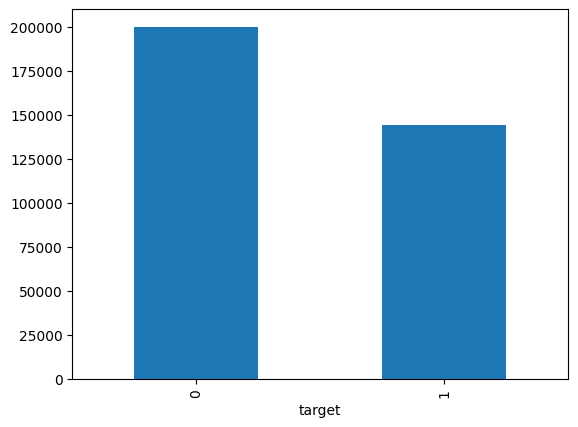

In [159]:
import matplotlib.pyplot as plt

sample_df["target"].value_counts().plot(
    kind="bar"
)
plt.show()

In [160]:
extra = identity_non_toxic.sample(
    n=20000,
    replace=True,
    random_state=42
)

sample_df = pd.concat(
    [sample_df, extra],
    ignore_index=True
)

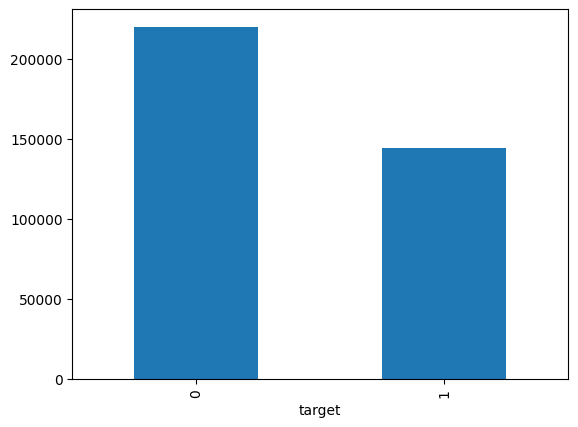

In [161]:
import matplotlib.pyplot as plt

sample_df["target"].value_counts().plot(
    kind="bar"
)
plt.show()

In [162]:
sample_df["target"].value_counts()

target
0    220000
1    144334
Name: count, dtype: int64

In [163]:
# training_args = TrainingArguments(
#     output_dir="./results",

#     num_train_epochs=1,

#     per_device_train_batch_size=16,

#     per_device_eval_batch_size=16,

#     eval_strategy="epoch",

#     save_strategy="epoch",

#     report_to="none"
# )

In [185]:
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=1,   # good for first experiment

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    eval_strategy="epoch",
    save_strategy="epoch",

    weight_decay=0.01,

    logging_steps=500,

    fp16=True,   # Kaggle T4/V100

    report_to="none"
)

In [164]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

In [165]:
identity_cols = [
    'asian', 'atheist', 'bisexual', 'black', 'buddhist',
    'christian', 'female', 'heterosexual', 'hindu',
    'homosexual_gay_or_lesbian',
    'intellectual_or_learning_disability',
    'jewish', 'latino', 'male', 'muslim',
    'other_disability', 'other_gender',
    'other_race_or_ethnicity', 'other_religion',
    'other_sexual_orientation',
    'physical_disability',
    'psychiatric_or_mental_illness',
    'transgender', 'white'
]

In [166]:
identity_non_toxic = train_df[
    (train_df["target"] == 0) &
    (train_df[identity_cols] >= 0.5).any(axis=1)
]

In [167]:
train_df, val_df = train_test_split(
    sample_df,
    test_size=0.2,
    stratify=sample_df["target"],
    random_state=42
)

In [168]:
train_df.columns

Index(['id', 'target', 'comment_text', 'severe_toxicity', 'obscene',
       'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual',
       'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu',
       'homosexual_gay_or_lesbian', 'intellectual_or_learning_disability',
       'jewish', 'latino', 'male', 'muslim', 'other_disability',
       'other_gender', 'other_race_or_ethnicity', 'other_religion',
       'other_sexual_orientation', 'physical_disability',
       'psychiatric_or_mental_illness', 'transgender', 'white', 'created_date',
       'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow',
       'sad', 'likes', 'disagree', 'sexual_explicit',
       'identity_annotator_count', 'toxicity_annotator_count'],
      dtype='object')

In [169]:
identity_non_toxic = train_df[
    (train_df["target"] == 0) &
    (train_df[identity_cols] >= 0.5).any(axis=1)
]

In [170]:
extra = identity_non_toxic.sample(
    n=20000,
    replace=True,
    random_state=42
)

In [171]:
train_df = pd.concat(
    [train_df, extra],
    ignore_index=True
)

In [172]:
train_texts = train_df["comment_text"].tolist()
train_labels = train_df["target"].tolist()

val_texts = val_df["comment_text"].tolist()
val_labels = val_df["target"].tolist()

In [173]:
print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))

Training samples: 311467
Validation samples: 72867


In [174]:
print(train_df["target"].value_counts())

print("\nValidation")
print(val_df["target"].value_counts())

target
0    196000
1    115467
Name: count, dtype: int64

Validation
target
0    44000
1    28867
Name: count, dtype: int64


In [175]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

AttributeError: 'list' object has no attribute 'tolist'

In [176]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [177]:
print(train_encodings["input_ids"][0])
print(train_encodings["attention_mask"][0])


[101, 4171, 7807, 2005, 1996, 15279, 10047, 7135, 1045, 2572, 2469, 2009, 2001, 2074, 2019, 15709, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [178]:
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    "input_ids": val_encodings["input_ids"],
    "attention_mask": val_encodings["attention_mask"],
    "labels": val_labels.tolist()
})

AttributeError: 'list' object has no attribute 'tolist'

In [179]:
train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels
})

val_dataset = Dataset.from_dict({
    "input_ids": val_encodings["input_ids"],
    "attention_mask": val_encodings["attention_mask"],
    "labels": val_labels
})

In [180]:
print(train_dataset[0])

{'input_ids': [101, 4171, 7807, 2005, 1996, 15279, 10047, 7135, 1045, 2572, 2469, 2009, 2001, 2074, 2019, 15709, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'labels': 0}


In [182]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [184]:
from scipy.special import softmax

def compute_metrics(pred):
    labels = pred.label_ids

    probs = softmax(pred.predictions, axis=1)

    preds = np.argmax(probs, axis=1)

    positive_probs = probs[:, 1]

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc_score(labels, positive_probs)
    }

In [186]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [187]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.525487,0.512417,0.892530,0.862890,0.866387,0.864635,0.959087


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9734, training_loss=0.5657719709507268, metrics={'train_runtime': 2469.4862, 'train_samples_per_second': 126.126, 'train_steps_per_second': 3.942, 'total_flos': 1.0314805814297088e+16, 'train_loss': 0.5657719709507268, 'epoch': 1.0})

In [188]:
predictions = trainer.predict(val_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [189]:
print(predictions)

PredictionOutput(predictions=array([[ 2.1738195, -1.9436357],
       [ 2.9956992, -2.8433406],
       [ 1.4845656, -1.1839945],
       ...,
       [ 3.357785 , -3.1041913],
       [ 3.2452824, -3.0549846],
       [-1.3924035,  1.4322622]], shape=(72867, 2), dtype=float32), label_ids=array([0, 0, 0, ..., 0, 0, 1], shape=(72867,)), metrics={'test_loss': 0.5124170184135437, 'test_accuracy': 0.892530226302716, 'test_precision': 0.8628898702732543, 'test_recall': 0.8663872241660027, 'test_f1': 0.8646350106307583, 'test_roc_auc': 0.959087241014433, 'test_runtime': 180.8736, 'test_samples_per_second': 402.862, 'test_steps_per_second': 12.594})


In [190]:
predictions.predictions.shape

(72867, 2)

In [191]:
from scipy.special import softmax

probs = softmax(predictions.predictions, axis=1)

toxicity_scores = probs[:, 1]

In [192]:
print(toxicity_scores[:5])

[0.01602492 0.00290318 0.06485424 0.00208691 0.40508556]


In [193]:

val_df_eval = val_df.copy()

val_df_eval["distilbert_score"] = toxicity_scores

In [194]:
val_df_eval[
    ["comment_text", "target", "distilbert_score"]
].head()

,comment_text,target,distilbert_score
196852,my initial intimation that gary mason might we...,0,0.016025
3625,sounds like the va but pitts never wrote anyth...,0,0.002903
350688,good grief a mid life existential crisis which...,0,0.064854
193804,they may not have entered illegally their pare...,0,0.002087
319823,still mad bro,1,0.405086


In [204]:
identity_columns = [
    'asian', 'atheist', 'bisexual', 'black', 'buddhist',
    'christian', 'female', 'heterosexual', 'hindu',
    'homosexual_gay_or_lesbian',
    'intellectual_or_learning_disability',
    'jewish', 'latino', 'male', 'muslim',
    'other_disability', 'other_gender',
    'other_race_or_ethnicity', 'other_religion',
    'other_sexual_orientation',
    'physical_disability',
    'psychiatric_or_mental_illness',
    'transgender', 'white'
]

In [207]:
from sklearn.metrics import roc_auc_score
import numpy as np

def compute_subgroup_auc(df, subgroup, model_name):

    subgroup_examples = df[df[subgroup] >= 0.5]

    if len(subgroup_examples) < 2:
        return np.nan

    if subgroup_examples[TOXICITY_COLUMN].nunique() < 2:
        return np.nan

    return roc_auc_score(
        subgroup_examples[TOXICITY_COLUMN],
        subgroup_examples[model_name]
    )

In [208]:
def compute_bpsn_auc(df, subgroup, model_name):

    subgroup_negative_examples = df[
        (df[subgroup] >= 0.5) &
        (df[TOXICITY_COLUMN] < 0.5)
    ]

    background_positive_examples = df[
        (df[subgroup] < 0.5) &
        (df[TOXICITY_COLUMN] >= 0.5)
    ]

    examples = pd.concat([
        subgroup_negative_examples,
        background_positive_examples
    ])

    if len(examples) < 2:
        return np.nan

    if examples[TOXICITY_COLUMN].nunique() < 2:
        return np.nan

    return roc_auc_score(
        examples[TOXICITY_COLUMN],
        examples[model_name]
    )

In [209]:
def compute_bnsp_auc(df, subgroup, model_name):

    subgroup_positive_examples = df[
        (df[subgroup] >= 0.5) &
        (df[TOXICITY_COLUMN] >= 0.5)
    ]

    background_negative_examples = df[
        (df[subgroup] < 0.5) &
        (df[TOXICITY_COLUMN] < 0.5)
    ]

    examples = pd.concat([
        subgroup_positive_examples,
        background_negative_examples
    ])

    if len(examples) < 2:
        return np.nan

    if examples[TOXICITY_COLUMN].nunique() < 2:
        return np.nan

    return roc_auc_score(
        examples[TOXICITY_COLUMN],
        examples[model_name]
    )

In [210]:
bias_metrics_df = compute_bias_metrics_for_model(
    val_df_eval,
    identity_columns,
    "distilbert_score"
)

In [213]:
def calculate_overall_auc(df, model_name): # overall auc on whole dataset
    true_labels = df[TOXICITY_COLUMN]
    predicted_labels = df[model_name]
    return metrics.roc_auc_score(true_labels, predicted_labels)

'''
These two functions calculate the final, single-number Jigsaw Evaluation Metric used to score models in the toxicity competition.
'''

def power_mean(series, p):
    total = sum(np.power(series, p))
    return np.power(total / len(series), 1 / p)

'''
When p is a large negative number, the math heavily shifts focus toward the lowest scores. If your model has an AUC of 0.99 on nine subgroups but a terrible AUC
of 0.50 on just one subgroup, the power mean will pull the entire average down drastically close to 0.50. This prevents a model from looking "fair" just by doing
well on average while failing a specific minority group.
'''

def get_final_metric(bias_df, overall_auc, POWER=-5, OVERALL_MODEL_WEIGHT=0.25):
    bias_score = np.average([
        power_mean(bias_df[SUBGROUP_AUC], POWER),
        power_mean(bias_df[BPSN_AUC], POWER),
        power_mean(bias_df[BNSP_AUC], POWER)
    ])
    return (OVERALL_MODEL_WEIGHT * overall_auc) + ((1 - OVERALL_MODEL_WEIGHT) * bias_score) # model weight contributes 25% while bias contributes 75% to final metric.

In [212]:
overall_auc = calculate_overall_auc(
    val_df_eval,
    "distilbert_score"
)

final_metric = get_final_metric(
    bias_metrics_df,
    overall_auc
)

print("Overall AUC:", overall_auc)
print("Final Bias Metric:", final_metric)

bias_metrics_df.sort_values("subgroup_auc").head(10)

Overall AUC: 0.959087241014433
Final Bias Metric: 0.8781613420741587


,subgroup,subgroup_auc,bpsn_auc,bnsp_auc
20,physical_disability,0.500000,0.823446,0.764463
10,intellectual_or_learning_disability,0.666667,0.992852,0.631287
18,other_religion,0.780000,0.856411,0.910303
8,hindu,0.833977,0.967348,0.781204
11,jewish,0.871431,0.916291,0.903436
7,heterosexual,0.888109,0.936234,0.888816
2,bisexual,0.891534,0.972732,0.803474
9,homosexual_gay_or_lesbian,0.891696,0.928015,0.906804
12,latino,0.891964,0.919559,0.914870
3,black,0.894605,0.901104,0.934113


In [220]:
import torch.nn.functional as F

In [ ]:
def predict_toxicity(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)

    pred = torch.argmax(probs, dim=1).item()

    label = "Toxic" if pred == 1 else "Non-Toxic"

    return {
        "text": text,
        "label": label,
        "confidence": float(probs[0][pred]),
        "non_toxic_prob": float(probs[0][0]),
        "toxic_prob": float(probs[0][1]),
    }

In [ ]:
predict_toxicity("He is black.")

In [222]:
preds = np.argmax(
    predictions.predictions,
    axis=1
)

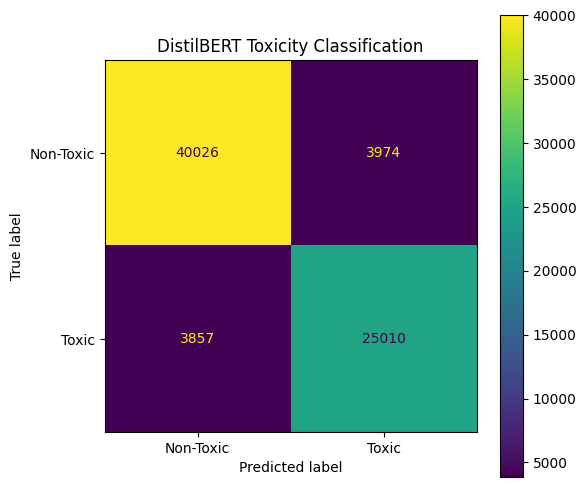

In [224]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Toxic", "Toxic"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="viridis",
    values_format="d",   # <-- integer format
    ax=ax
)

plt.title("DistilBERT Toxicity Classification")
plt.show()

In [226]:
print(
    classification_report(
        val_labels,
        preds,
        target_names=["Non-Toxic", "Toxic"]
    )
)

              precision    recall  f1-score   support

   Non-Toxic       0.91      0.91      0.91     44000
       Toxic       0.86      0.87      0.86     28867

    accuracy                           0.89     72867
   macro avg       0.89      0.89      0.89     72867
weighted avg       0.89      0.89      0.89     72867



In [227]:
model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [228]:
!pip install torchinfo -q
from torchinfo import summary

summary(
    model,
    input_size=(1, 128),
    dtypes=[torch.long]
)

Layer (type:depth-idx)                                  Output Shape              Param #
DistilBertForSequenceClassification                     [1, 2]                    --
├─DistilBertModel: 1-1                                  [1, 128, 768]             --
│    └─Embeddings: 2-1                                  [1, 128, 768]             --
│    │    └─Embedding: 3-1                              [1, 128, 768]             23,440,896
│    │    └─Embedding: 3-2                              [1, 128, 768]             393,216
│    │    └─LayerNorm: 3-3                              [1, 128, 768]             1,536
│    │    └─Dropout: 3-4                                [1, 128, 768]             --
│    └─Transformer: 2-2                                 [1, 128, 768]             --
│    │    └─ModuleList: 3-5                             --                        42,527,232
├─Linear: 1-2                                           [1, 768]                  590,592
├─Dropout: 1-3                 

In [229]:
print(model.config)

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForSequenceClassification"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "problem_type": "single_label_classification",
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "use_cache": false,
  "vocab_size": 30522
}



In [230]:
from sklearn.metrics import roc_auc_score
import scipy.special as sp

probs = sp.softmax(
    predictions.predictions,
    axis=1
)

toxic_probs = probs[:,1]

auc = roc_auc_score(
    val_labels,
    toxic_probs
)

print("ROC AUC:", auc)

ROC AUC: 0.959087241014433


In [231]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    val_labels,
    toxic_probs
)

print("PR AUC:", pr_auc)

PR AUC: 0.9408950448079859


In [232]:
trainer.save_model(
    "./distilbert_toxicity_model"
)

tokenizer.save_pretrained(
    "./distilbert_toxicity_model"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./distilbert_toxicity_model/tokenizer_config.json',
 './distilbert_toxicity_model/tokenizer.json')

In [233]:
!ls distilbert_toxicity_model

config.json	   tokenizer_config.json  training_args.bin
model.safetensors  tokenizer.json


In [234]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

model_path = "./distilbert_toxicity_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(
    model_path
)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully!


In [239]:
predict_toxicity(
    "You are stupid"
)



{'text': 'You are stupid',
 'label': 'Toxic',
 'confidence': 0.9987112283706665,
 'non_toxic_prob': 0.0012887758202850819,
 'toxic_prob': 0.9987112283706665}

In [240]:
predict_toxicity(
    "I hate you"
)

{'text': 'I hate you',
 'label': 'Toxic',
 'confidence': 0.810225784778595,
 'non_toxic_prob': 0.18977420032024384,
 'toxic_prob': 0.810225784778595}